<a href="https://www.kaggle.com/code/ayaalharazin/detecting-bias-in-salary-prediction?scriptVersionId=320343164" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 1. Introduction

Machine learning models learn patterns from historical data.

But what happens if the historical data itself contains unfair patterns?

In this notebook, we will explore how biased salary data can influence machine learning predictions using a simple Linear Regression model.

We will:
- Analyze the dataset
- Visualize salary bias
- Train a regression model
- Compare predictions
- Observe unfair outcomes
- Discuss Responsible AI concepts

# 2. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# 3. Load Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/ayaalharazin/biased-salary-dataset/biased_salary_dataset.csv')

df.head()

,Employee_ID,Gender,Age,Experience_Years,Education_Level,City,Salary
0,1,Male,45,0,Master,Ramallah,7099
1,2,Male,40,2,PhD,Nablus,10056
2,3,Male,38,7,High School,Jenin,9540
3,4,Female,36,7,Master,Nablus,11502
4,5,Male,32,13,Master,Ramallah,17020


# 4. Dataset Exploration

In [3]:
df.shape

(1000, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Employee_ID       1000 non-null   int64 
 1   Gender            1000 non-null   object
 2   Age               1000 non-null   int64 
 3   Experience_Years  1000 non-null   int64 
 4   Education_Level   1000 non-null   object
 5   City              1000 non-null   object
 6   Salary            1000 non-null   int64 
dtypes: int64(4), object(3)
memory usage: 54.8+ KB


In [5]:
df.describe()

,Employee_ID,Age,Experience_Years,Salary
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,36.069000,7.647000,11592.339000
std,288.819436,8.432517,4.568289,3774.335378
min,1.000000,22.000000,0.000000,2626.000000
25%,250.750000,29.000000,4.000000,8751.500000
50%,500.500000,36.000000,8.000000,11706.000000
75%,750.250000,44.000000,12.000000,14425.750000
max,1000.000000,50.000000,15.000000,21056.000000


In [6]:
df.isnull().sum()

Employee_ID         0
Gender              0
Age                 0
Experience_Years    0
Education_Level     0
City                0
Salary              0
dtype: int64

# 5. Visualize Bias

## 5.1 Salary Distribution by Gender

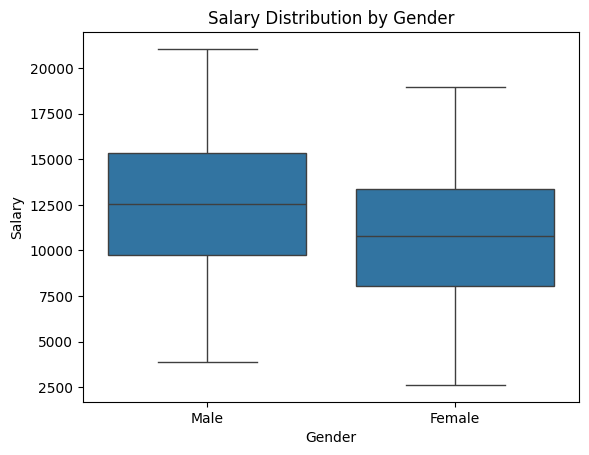

In [7]:
sns.boxplot(x='Gender', y='Salary', data=df)
plt.title('Salary Distribution by Gender')
plt.show()

## 5.2 Average Salary Comparison

In [8]:
df.groupby('Gender')['Salary'].mean()

Gender
Female    10687.495127
Male      12545.490760
Name: Salary, dtype: float64

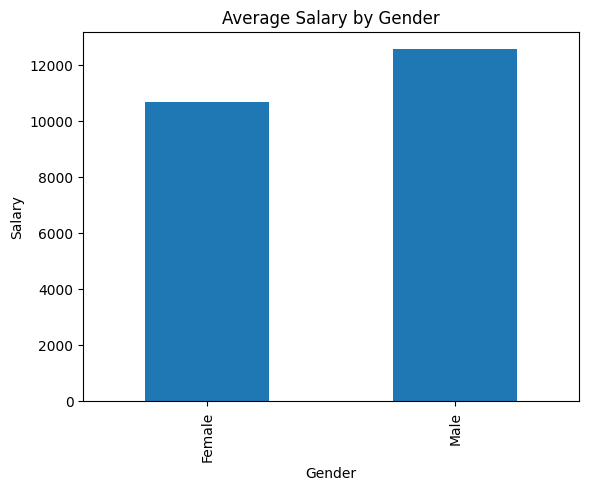

In [9]:
df.groupby('Gender')['Salary'].mean().plot(kind='bar')
plt.title('Average Salary by Gender')
plt.ylabel('Salary')
plt.show()

## 5.3 Observation

We can clearly observe that male employees tend to receive higher salaries than female employees even when other factors are similar.

This indicates that the dataset contains historical-style gender bias patterns.

# 6. Data Preprocessing

In [10]:
encoder = LabelEncoder()

df['Gender'] = encoder.fit_transform(df['Gender'])
df['Education_Level'] = encoder.fit_transform(df['Education_Level'])
df['City'] = encoder.fit_transform(df['City'])

# 7. Feature Selection

In [11]:
X = df[['Gender', 'Age', 'Experience_Years', 'Education_Level', 'City']]
y = df['Salary']

# 8. Train/Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 9. Train Linear Regression Model

In [13]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

# 10. Evaluate Model

In [14]:
predictions = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, predictions))
print("R2 Score:", r2_score(y_test, predictions))

MAE: 946.8473655350755
R2 Score: 0.9132370200793071


# 11. MOST IMPORTANT — Fairness Experiment

## 11.1 Male Prediction

In [15]:
male = [[1, 30, 5, 1, 1]]
model.predict(male)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([9879.31519651])

## 11.2 Female Prediction

In [16]:
female = [[0, 30, 5, 1, 1]]
model.predict(female)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([8118.3723696])

# 12. Explain the Result

# 12.1 Fairness Observation

Even when experience, age, education, and city remain the same, the model predicts different salaries based on gender.

This demonstrates how machine learning models can learn and reproduce historical bias patterns from training data.

# 13. Responsible AI Discussion

# Responsible AI Discussion

Machine learning models are not inherently fair or unfair.

They learn patterns from data.

If historical data contains unfair treatment or social inequalities, the model may reproduce those patterns in future predictions.

This is why fairness evaluation, bias detection, and responsible AI practices are critical when developing AI systems.

# 13. Final Conclusion

# Conclusion

In this notebook, we explored how biased historical salary data can influence machine learning predictions.

Using a simple Linear Regression model, we demonstrated that:
- AI models learn patterns from data
- Biased data can produce unfair outcomes
- Responsible AI practices are important for ethical ML systems

This project highlights the importance of fairness-aware machine learning and careful dataset analysis.